# Error Normalized Distance Simulations
A first study of the ideal error normalized distance distributions was done in 'crossmatch_analysis.ipynb'

In this notebook, we include all code and plots to study how error normalized distributions should behave, and change under varying distances and covariances

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')

from plotting_functions import set_styles
from astrometry_equations import rayleigh, compute_error_normalized_distance
set_styles()

# Simulate

In [43]:
# MOVE SOMEWHERE ELSE
def simulate_error_normalized_distance(num_samples, method='full'):
    """Simulates num_samples pairs of data points and computes the error normalized distances between them

    TODO: Expand documentation, expand flexibility of code"""

    dist_mean = [0,0]
    sigma_x1, sigma_y1, sigma_xy1 = 0.7, 0.4, 0.2
    sigma_x2, sigma_y2, sigma_xy2 = 0.5, 0.4, 0.3

    cov1 = [[sigma_x1, sigma_xy1], [sigma_xy1, sigma_y1]]
    cov2 = [[sigma_x2, sigma_xy2], [sigma_xy2, sigma_y2]]
    pos1 = np.random.multivariate_normal(dist_mean, cov1, num_samples)
    pos2 = np.random.multivariate_normal(dist_mean, cov2, num_samples)

    unc1 = np.array([np.full(num_samples, sigma_x1), np.full(num_samples, sigma_y1), np.full(num_samples, sigma_xy1)]).T
    unc2 = np.array([np.full(num_samples, sigma_x2), np.full(num_samples, sigma_y2), np.full(num_samples, sigma_xy2)]).T

    print(unc1.shape, pos1.shape, unc2.shape, pos2.shape)
    en_dist = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method=method)

    return en_dist

num_samples = 100000
error_normalized_distances = simulate_error_normalized_distance(num_samples, method='full')

(100000, 3) (100000, 2) (100000, 3) (100000, 2)


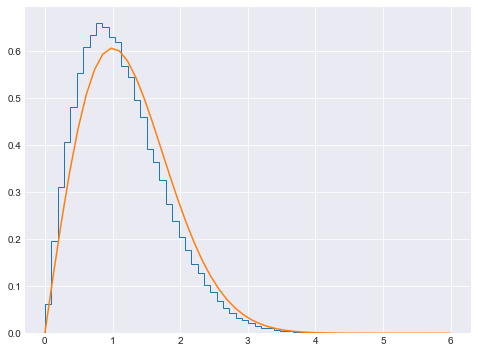

In [44]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.hist(error_normalized_distances, bins=50, histtype='step', density=True)
x = np.linspace(0,6,50)
ax.plot(x, rayleigh(x,1))
plt.show()